# Appendix D — Data Pre-processing
**Report:** Visual Place Recognition for Loop Closure Detection in GNSS Denied UAV Navigation  
**Author:** William Kevin Morley — Stellenbosch University, November 2025

This notebook reproduces every result in **Appendix D** of the report.  
All heavy lifting lives in two helper modules under `scripts/`:

| Module | Covers |
|---|---|
| `scripts/imu.py` | §D.2.1 — GoPro sync, PSD, filter design, IMU takeoff |
| `scripts/telemetry.py` | §D.2.2 — UAV telemetry cleaning, timeline repair, GPS takeoff |
| `scripts/postprocessing.py` | §3.3 — Flight segment classification (STATE / SUBSTATE) |

> **Repo layout assumed:**  
> ```
> project/
> ├── data.ipynb          ← this notebook
> ├── scripts/
> │   ├── imu.py
> │   ├── telemetry.py
> │   └── postprocessing.py
> ├── f1_c1_imu.csv, f1_c2_imu.csv, ...   (raw sensor CSVs)
> ├── f1_gps_raw.csv, f2_gps_raw.csv       (raw telemetry)
> └── figures/                              (saved plots)
> ```


## 0. Setup — Imports & Data Loading

In [2]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts import imu, telemetry
from scripts.postprocessing import processor as postp

# ── Raw IMU (high-frequency) ──
f1_c1_imu = pd.read_csv('../f1_c1_imu.csv')
f1_c2_imu = pd.read_csv('../f1_c2_imu.csv')
f2_c1_imu = pd.read_csv('../f2_c1_imu.csv')
f2_c2_imu = pd.read_csv('../f2_c2_imu.csv')

# ── Raw Orientation (low-frequency) ──
f1_c1_orient = pd.read_csv('../f1_c1_orient.csv')
f1_c2_orient = pd.read_csv('../f1_c2_orient.csv')
f2_c1_orient = pd.read_csv('../f2_c1_orient.csv')
f2_c2_orient = pd.read_csv('../f2_c2_orient.csv')

# ── Raw GPS Telemetry ──
f1_gps = pd.read_csv('../f1_gps_raw.csv')
f2_gps = pd.read_csv('../f2_gps_raw.csv')

print("All data loaded.")
print(f"  Flight 1 IMU:    {len(f1_c1_imu):,} samples @ ~{1/np.median(np.diff(f1_c1_imu['time'])):.1f} Hz")
print(f"  Flight 2 IMU:    {len(f2_c1_imu):,} samples @ ~{1/np.median(np.diff(f2_c1_imu['time'])):.1f} Hz")
print(f"  Flight 1 GPS:    {len(f1_gps):,} rows")
print(f"  Flight 2 GPS:    {len(f2_gps):,} rows")


/home/w1ll/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


All data loaded.
  Flight 1 IMU:    1,389,627 samples @ ~202.8 Hz
  Flight 2 IMU:    1,406,442 samples @ ~202.8 Hz
  Flight 1 GPS:    351,473 rows
  Flight 2 GPS:    118,230 rows


---
## §D.2.1 GoPro Data Sources

> **Note:** §D.2.1.1 (Lens Correction) and §D.2.1.2 (Lens Scaling) were performed  
> externally using [Gyroflow](https://github.com/gyroflow/gyroflow) and are documented  
> in the report only. This notebook begins at §D.2.1.3.


### §D.2.1.3 Synchronising Cameras and Sensors (Table D.5)

Cross-correlation of IMU magnitude signals and orientation angular velocities  
determines the frame offset between Camera 1 and Camera 2 for each flight.


In [3]:
# Merge orientation DataFrames for low-frequency sync
f1_orient = pd.merge(f1_c1_orient, f1_c2_orient, on='time', suffixes=('_c1', '_c2'))
f2_orient = pd.merge(f2_c1_orient, f2_c2_orient, on='time', suffixes=('_c1', '_c2'))

# Build the full sync table (Table D.5)
sync_table = imu.run_full_sync_table(
    imu_pairs=[('Flight 1', f1_c1_imu, f1_c2_imu),
               ('Flight 2', f2_c1_imu, f2_c2_imu)],
    orient_pairs=[('Flight 1', f1_orient),
                  ('Flight 2', f2_orient)],
)
display(sync_table)
print("\nConclusion: Flight 1 offset = +266 frames (C1 leads)")
print("            Flight 2 offset = -10  frames (C2 leads)")


,Flight,Signal,Sampling Rate (Hz),Best Lag (Samples),Best Lag (ms),Lag (Frames),Correlation,Status
0,Flight 1,GYRO 0,202.8,2220,10946.9,263,0.4445,C1 Leads
1,Flight 1,GYRO 1,202.8,2195,10823.6,260,0.1112,C1 Leads
2,Flight 1,GYRO 2,202.8,2253,11109.6,266,0.3463,C1 Leads
3,Flight 1,GYRO MAG,202.8,2246,11075.1,266,0.2472,C1 Leads
4,Flight 1,ACCL 0,202.8,2198,10838.4,260,0.1928,C1 Leads
5,Flight 1,ACCL 1,202.8,2137,10537.6,253,-0.0820,C1 Leads
6,Flight 1,ACCL 2,202.8,2176,10729.9,257,0.0538,C1 Leads
7,Flight 1,ACCL MAG,202.8,2186,10779.2,258,0.0740,C1 Leads
8,Flight 2,GYRO 0,202.8,-106,-522.7,-13,0.4023,C2 Leads
9,Flight 2,GYRO 1,202.8,-109,-537.5,-13,-0.1563,C2 Leads



Conclusion: Flight 1 offset = +266 frames (C1 leads)
            Flight 2 offset = -10  frames (C2 leads)


#### Apply Offsets and Save Synchronised Datasets

In [4]:
# Synchronise using the offsets from Table D.5
f1_imu = imu.sync_and_truncate(f1_c1_imu, f1_c2_imu, offset=2253, c1_leads=True)
f2_imu = imu.sync_and_truncate(f2_c1_imu, f2_c2_imu, offset=87,   c1_leads=False)
f1_orient_sync = imu.sync_and_truncate(f1_c1_orient, f1_c2_orient, offset=266, c1_leads=True)
f2_orient_sync = imu.sync_and_truncate(f2_c1_orient, f2_c2_orient, offset=10,  c1_leads=False)

# Persist for downstream notebooks
f1_imu.to_csv('../f1_imu.csv', index=False)
f2_imu.to_csv('../f2_imu.csv', index=False)
f1_orient_sync.to_csv('../f1_orient.csv', index=False)
f2_orient_sync.to_csv('../f2_orient.csv', index=False)
print(f"Saved synced datasets: f1_imu ({len(f1_imu):,}), f2_imu ({len(f2_imu):,})")


Saved synced datasets: f1_imu (1,383,060), f2_imu (1,343,655)


### §D.2.1.4 Power Spectral Density Analysis (Figure D.2)

Welch's method reveals a clear separation between low-frequency aircraft dynamics  
(< 10 Hz) and high-frequency vibrational noise (> 20 Hz), justifying low-pass filtering.


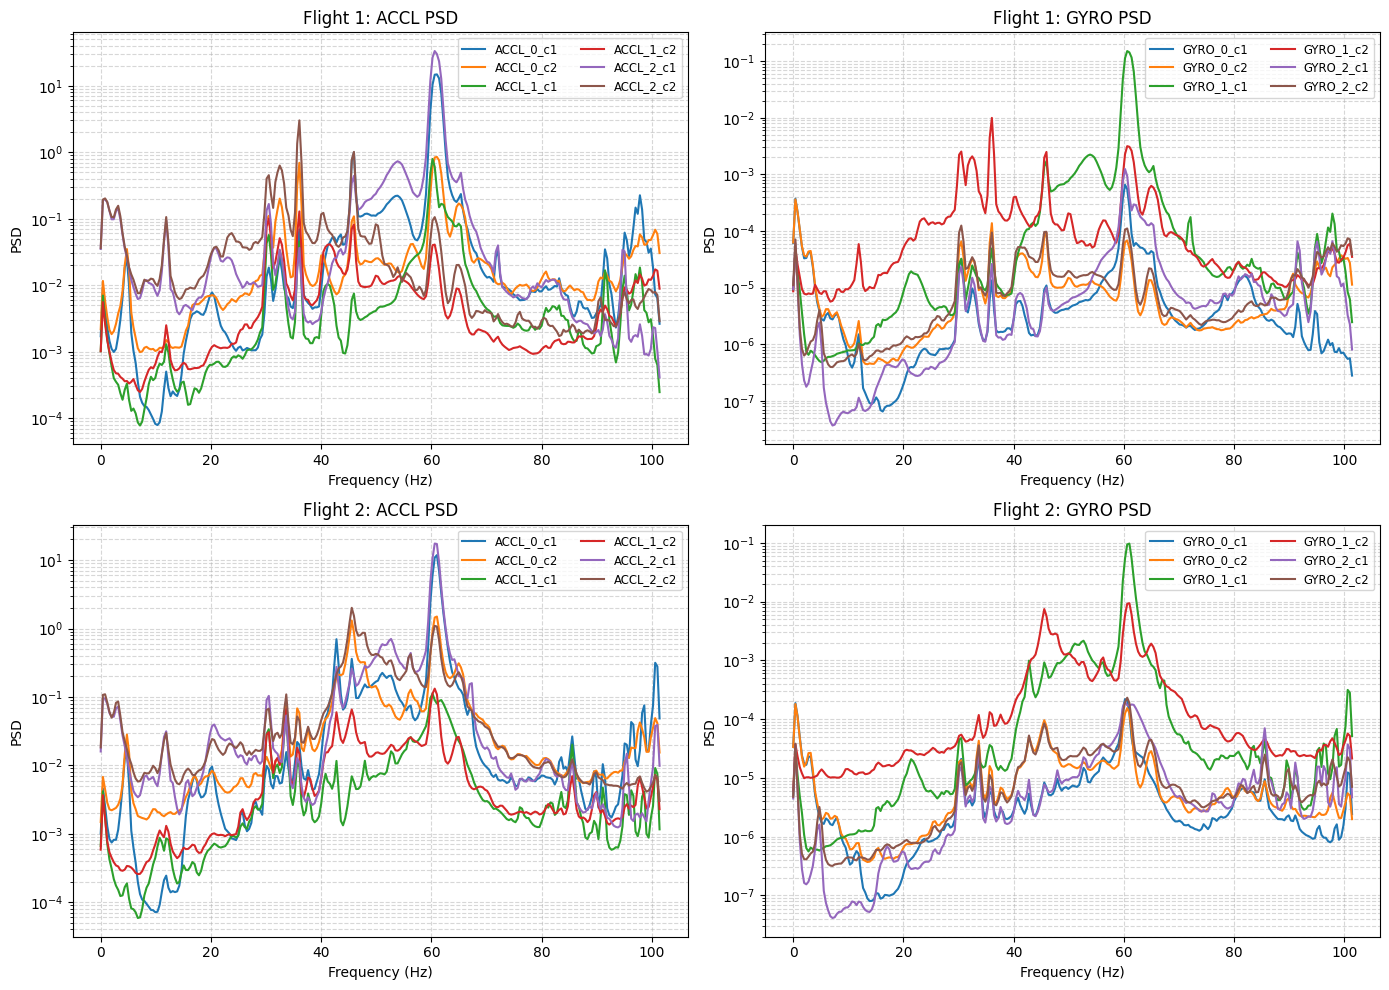

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

imu.plot_psd(f1_imu, 'ACCL', 'Flight 1', ax=axes[0, 0])
imu.plot_psd(f1_imu, 'GYRO', 'Flight 1', ax=axes[0, 1])
imu.plot_psd(f2_imu, 'ACCL', 'Flight 2', ax=axes[1, 0])
imu.plot_psd(f2_imu, 'GYRO', 'Flight 2', ax=axes[1, 1])

plt.tight_layout()
plt.savefig('figures/fig_d2_psd.png', dpi=200)
plt.show()

### §D.2.1.5 Filter Design and Application (Table D.6 / Figure D.3)

A 4th-order Butterworth low-pass filter is applied per channel.  
Cutoffs are optimised by minimising RMS error between C1 and C2.  
ACCL_1 is overridden to 0.2 Hz (see report for justification).


In [6]:
# Optimise cutoffs (Table D.6)
f1_filt, f1_table = imu.optimize_filters(f1_imu, 'Flight 1')
f2_filt, f2_table = imu.optimize_filters(f2_imu, 'Flight 2')
display(pd.concat([f1_table, f2_table], ignore_index=True))


,Flight,Channel,Raw Correl.,Filt. Correl.,Cutoff (Hz)
0,Flight 1,ACCL_0,0.047,0.927,0.3
1,Flight 1,ACCL_1,-0.058,-0.183,0.2
2,Flight 1,ACCL_2,0.011,0.819,0.2
3,Flight 1,GYRO_0,0.306,0.961,0.1
4,Flight 1,GYRO_1,0.029,0.838,2.9
5,Flight 1,GYRO_2,0.218,0.996,0.1
6,Flight 2,ACCL_0,-0.084,0.997,0.1
7,Flight 2,ACCL_1,-0.006,-0.388,0.2
8,Flight 2,ACCL_2,-0.059,0.955,0.1
9,Flight 2,GYRO_0,0.302,0.989,0.1


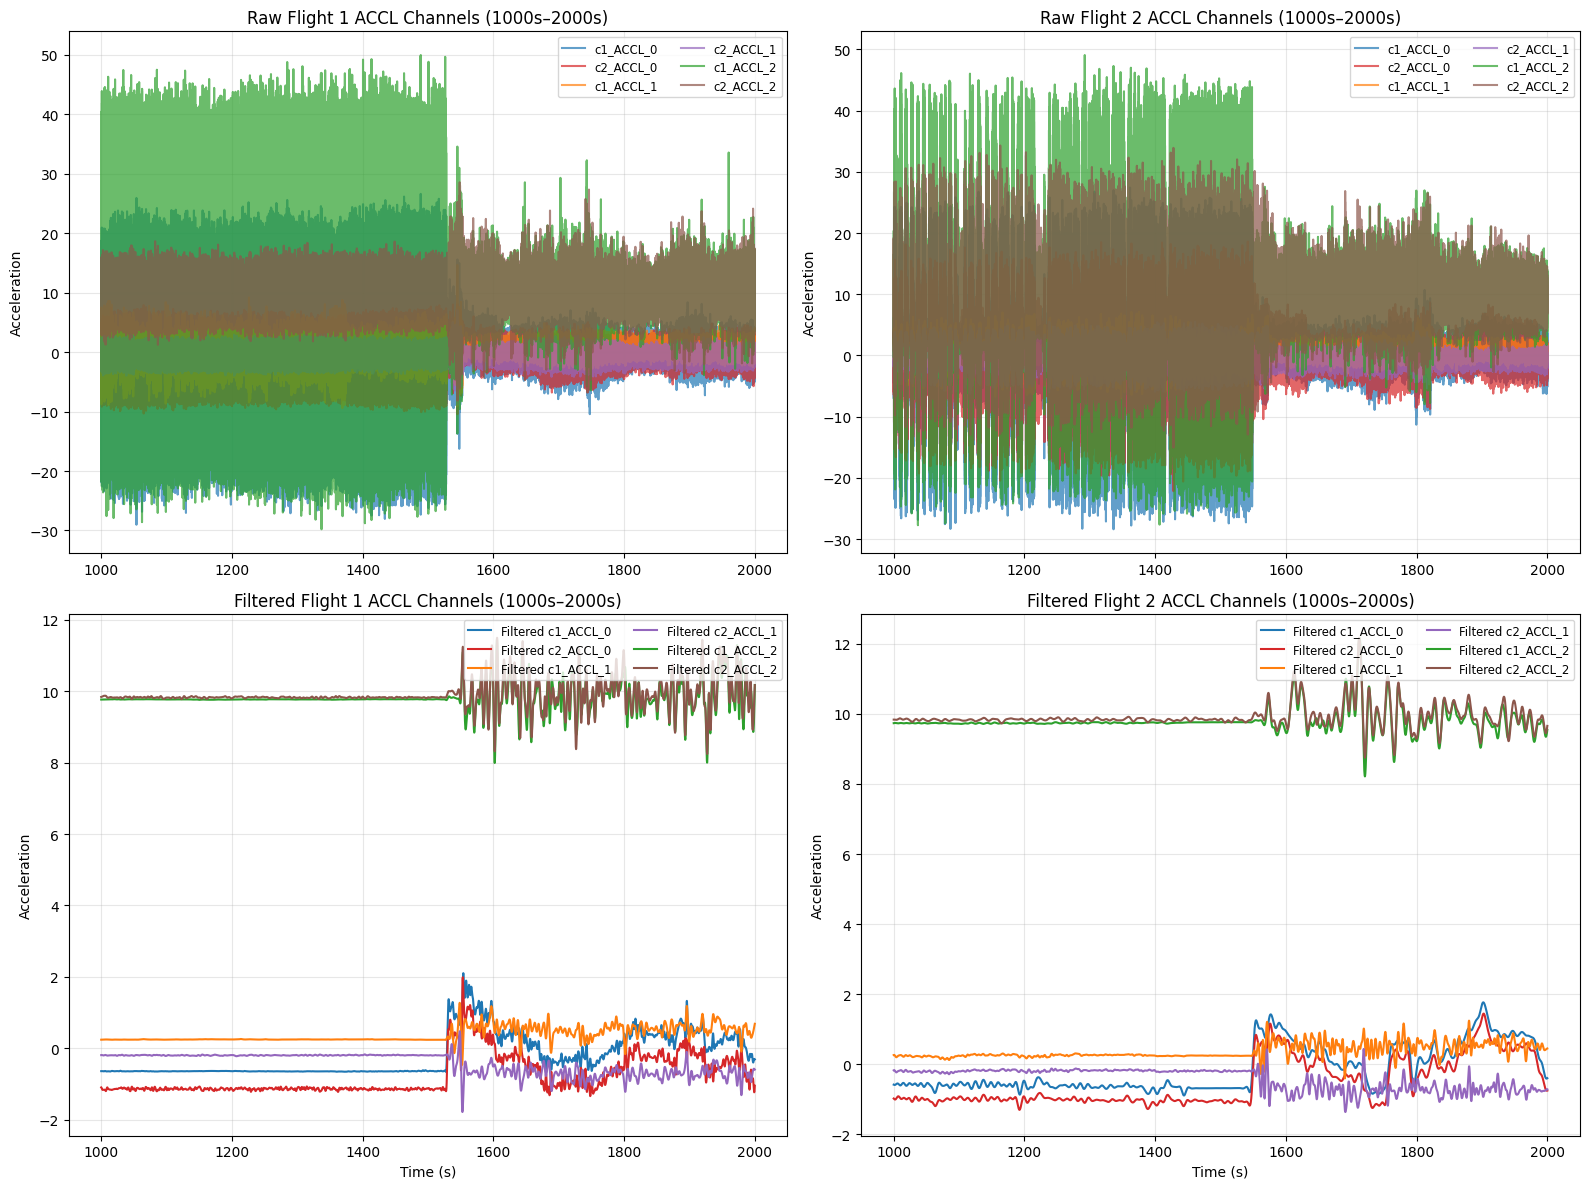

In [7]:
# Figure D.3 — raw vs filtered accelerometer
imu.plot_raw_vs_filtered_accl(f1_imu, f1_filt, f2_imu, f2_filt,
                               save_path='figures/fig_d3_accl.png')


### §D.2.1.6 Identification of Takeoff (Algorithm 3.1 / Table D.7)

Takeoff is detected when the averaged longitudinal accelerometer exceeds  
a 0 m/s² threshold for a sustained 2020 samples (~10 seconds).


In [8]:
# Apply Table D.6 cutoffs then run Algorithm 3.1
f1_imu_strict = imu.apply_table_d6_filters(f1_filt, 'F1')
f2_imu_strict = imu.apply_table_d6_filters(f2_filt, 'F2')

results = []
for label, df_f, cam in [('Flight 1', f1_imu_strict, 'C2'),
                          ('Flight 2', f2_imu_strict, 'C1')]:
    idx = imu.detect_imu_takeoff(df_f)
    if idx is not None:
        t = df_f['time'].iloc[idx]
        results.append({'Flight': label, 'Takeoff Time (s)': round(t, 2),
                        'Frame': int(t * 23.98), 'Reference Camera': cam})

display(pd.DataFrame(results))  # Table D.7


,Flight,Takeoff Time (s),Frame,Reference Camera
0,Flight 1,1529.45,36676,C2
1,Flight 2,1549.58,37158,C1


---
## §D.2.2 UAV Telemetry


### §D.2.2.1 Flight 1: Preparation, Cleaning and Re-sampling

1. Parse DATE/TIME → COUNT_TIME  
2. Outlier removal → NaN  
3. Linear interpolation + rolling median  
4. Savitzky–Golay smoothing (Figure D.5)  
5. GPS polling rate estimation (Figure D.6)


In [9]:
# Step 1 — Parse timeline
f1_gps = telemetry.radians_to_degrees(f1_gps, ["LATITUDE", "LONGITUDE", "HEADING"])
f1_gps, f1_freq = telemetry.process_f1_time(f1_gps)
print(f"Estimated COUNT_TIME frequency: {f1_freq:.2f} Hz")

# Step 2–3 — Outlier removal + smoothing
FILTERS = [
    ('LONGITUDE', 20.10, 22.0), ('LATITUDE', -35.0, -22.0),
    ('GND_SPD', 0, 100),        ('ALTITUDE', 0, 5000),
    ('HEADING', -180, 180),     ('AIR_SPD', 0, 120),
]
f1_gps_filtered  = telemetry.apply_outlier_filters(f1_gps, FILTERS)
f1_gps_smoothed  = telemetry.interpolate_and_smooth(f1_gps_filtered, window=3)


Estimated COUNT_TIME frequency: 32.45 Hz


In [10]:
# Figure D.4 — raw vs smoothed GPS
FIELDS = ["LONGITUDE", "LATITUDE", "GND_SPD", "ALTITUDE", "HEADING", "AIR_SPD"]
telemetry.plot_gps_comparison(f1_gps_filtered, f1_gps_smoothed, FIELDS,
                              save_path='figures/fig_d4_f1_gps.png')


In [11]:
# Figure D.5 — Savitzky-Golay detail
telemetry.apply_sg_filter(f1_gps_smoothed.copy(), save_path='figures/fig_d5_savgol.png')


In [12]:
# Figure D.6 — GPS polling rate estimation
result = telemetry.estimate_gps_polling(f1_gps_smoothed)
print(f"RMSE-optimal freq:  {result['opt_freq_rmse']:.1f} Hz")
print(f"MedAE-optimal freq: {result['opt_freq_medae']:.1f} Hz")
result['plot'](save_path='figures/fig_d6_polling.png')


RMSE-optimal freq:  33.1 Hz
MedAE-optimal freq: 33.7 Hz


### §D.2.2.2 Flight 2: Preparation and Cleaning

1. Repair sawtooth timeline → SHIFTED_TIME (Figure D.7)  
2. Duplicate analysis (Table D.8)  
3. Linear interpolation of flying duplicates


In [13]:
# Step 1 — Timeline repair
df_f2, f2_freq, _ = telemetry.repair_timeline(f2_gps)
print(f"Median frequency: {f2_freq:.2f} Hz")
telemetry.plot_timeline_reconstruction(df_f2, save_path='figures/fig_d7_timeline.png')


Median frequency: 10.00 Hz


In [14]:
# Table D.8 — duplicate analysis
display(telemetry.analyze_duplicates_by_speed(df_f2))

# Clean duplicates
df_f2_clean, n_fixed, rmse = telemetry.clean_and_interpolate(df_f2, min_speed=0.5)
print(f"\nFixed {n_fixed} flying duplicates  |  RMSE: {rmse:.2f} m")

# Post-cleaning verification
display(telemetry.analyze_duplicates_by_speed(df_f2_clean))


,Total_Pairs,Duplicate_Pairs,Rate_%
bin,,,
Stationary,26512,26273,99.10
0–3 m/s,10668,5816,54.52
3–10 m/s,1970,930,47.21
10–30 m/s,1015,481,47.39
30–60 m/s,68661,32354,47.12
>60 m/s,9403,4435,47.17



Fixed 43564 flying duplicates  |  RMSE: 4.36 m


,Total_Pairs,Duplicate_Pairs,Rate_%
bin,,,
Stationary,26512,26273,99.10
0–3 m/s,10668,458,4.29
3–10 m/s,1970,0,0.00
10–30 m/s,1015,0,0.00
30–60 m/s,68661,0,0.00
>60 m/s,9403,0,0.00


### §D.2.2.3 Identification of Takeoff (Algorithm 3.2 / Table D.9)

In [15]:
# Flight 1
f1_to = telemetry.detect_gps_takeoff(f1_gps_smoothed, 2500, 2800, tau=0.5, time_col='COUNT_TIME')
print(f"Flight 1 takeoff (COUNT_TIME): {f1_to[1]:.1f} s" if f1_to else "Not detected")

# Flight 2 — both candidate timelines
f2_shifted = telemetry.detect_gps_takeoff(df_f2_clean, 3100, 3300, tau=0.5, time_col='SHIFTED_TIME')
f2_count   = telemetry.detect_gps_takeoff(df_f2_clean, 2800, 4000, tau=0.5, time_col='COUNT_TIME')
print(f"Flight 2 takeoff (SHIFTED_TIME): {f2_shifted[1]:.1f} s" if f2_shifted else "Not detected")
print(f"Flight 2 takeoff (COUNT_TIME):   {f2_count[1]:.1f} s"   if f2_count   else "Not detected")


Flight 1 takeoff (COUNT_TIME): 2725.1 s
Flight 2 takeoff (SHIFTED_TIME): 3187.7 s
Flight 2 takeoff (COUNT_TIME):   2900.4 s


---
## §3.3 Flight Segment Classification (Table 3.1 / Figures 3.1–3.2)

States are classified by altitude: TAXI → TAKEOFF → CRUISE_0 → ASCENT_1 → …  
Substates within CRUISE segments use heading: OUTBOUND / TURNING / INBOUND.


In [16]:
# ── Flight 2 (the validated dataset) ──
vlines = [3200, 3650, 4960, 5720, 7905, 8400, 11000]
labels = ["TAXI", "TAKEOFF", "CRUISE_0", "ASCENT_1",
          "CRUISE_1", "ASCENT_2", "CRUISE_2", "DESCENT"]

f2 = postp.get_flight_states(df_f2_clean, vlines, labels, time_col='SHIFTED_TIME')

# Automated heading-based substates
f2 = postp.classify_substate_auto(f2, 'CRUISE_0', threshold=10)
f2 = postp.classify_substate_auto(f2, 'CRUISE_1')
f2 = postp.classify_substate_freq(f2, 'CRUISE_2')

# Manual corrections for complex turns
f2 = postp.update_substate_manual(f2, 'CRUISE_0', 4100, 4350, 'INBOUND')
f2 = postp.update_substate_manual(f2, 'CRUISE_1', 6670, 6755, 'TURNING')
f2 = postp.update_substate_manual(f2, 'CRUISE_2', 8740, 8790, 'TURNING')

# Summary table
for state in ['CRUISE_0', 'CRUISE_1']:
    seg = f2[f2['STATE'] == state]
    for sub in ['OUTBOUND', 'TURNING', 'INBOUND']:
        s = seg[seg['SUBSTATE'] == sub]
        if len(s):
            print(f"{state} {sub:10s}  n={len(s):5d}  "
                  f"alt={s['ALTITUDE'].mean():.0f}m  spd={s['GND_SPD'].mean():.1f}m/s")


CRUISE_0 OUTBOUND    n= 5526  alt=431m  spd=35.4m/s
CRUISE_0 TURNING     n= 2131  alt=434m  spd=42.2m/s
CRUISE_0 INBOUND     n= 4176  alt=447m  spd=44.8m/s
CRUISE_1 OUTBOUND    n= 8451  alt=2190m  spd=54.5m/s
CRUISE_1 TURNING     n= 1296  alt=2182m  spd=47.9m/s
CRUISE_1 INBOUND     n=10011  alt=2172m  spd=46.2m/s


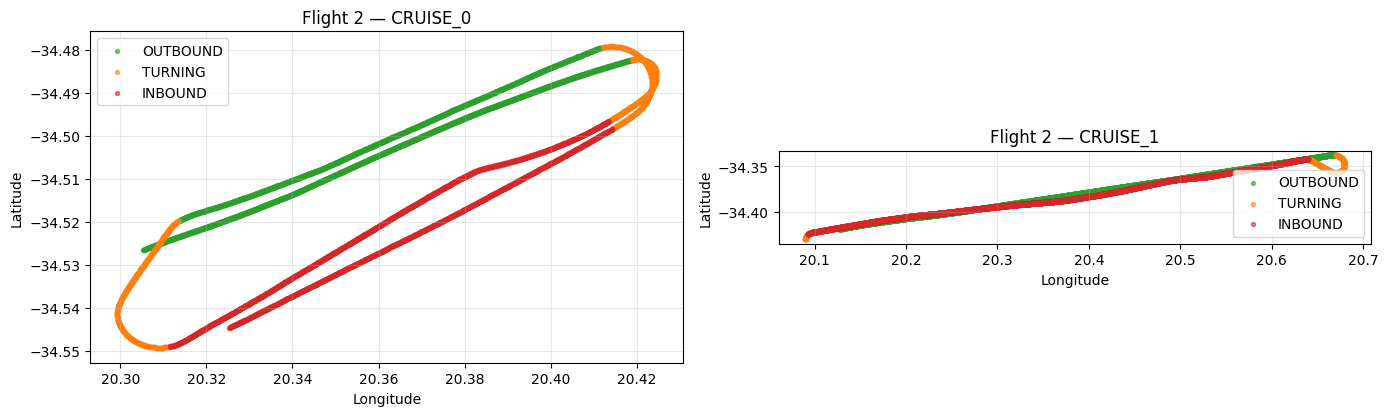

In [17]:
# Figure 3.2 — CRUISE segments coloured by SUBSTATE
color_map = {'OUTBOUND': '#2ca02c', 'TURNING': '#ff7f0e', 'INBOUND': '#d62728'}
cruise_data = f2[f2['STATE'].str.contains('CRUISE', na=False)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, state in zip(axes, ['CRUISE_0', 'CRUISE_1']):
    seg = cruise_data[cruise_data['STATE'] == state]
    for sub, color in color_map.items():
        s = seg[seg['SUBSTATE'] == sub]
        ax.scatter(s['LONGITUDE'], s['LATITUDE'], c=color, label=sub, s=8, alpha=0.6)
    ax.set_title(f"Flight 2 — {state}")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('figures/fig_3_2_substates.png', dpi=200)
plt.show()


---
## §3.4 Evaluation — Synchronisation and IMU Filter Validation

With both data streams pre-processed and takeoff identified, we now:
1. **Downsample** the high-frequency IMU and orientation data onto the telemetry timeline (SHIFTED_TIME) to create a single unified Flight 2 dataset.
2. **Evaluate the IMU filter** by comparing gyroscope-derived yaw and quaternion-derived yaw against telemetry HEADING (Table D.10 / Figure 3.3).
3. **Produce the summary table** (Table 3.1) for the classified CRUISE segments.

> Flight 1 was excluded due to unresolved synchronisation drift (see §3.4.2 in report).

In [18]:
from scipy.interpolate import interp1d

# ── Anchor: IMU takeoff (C1 frame) aligned to GPS takeoff (SHIFTED_TIME) ──
imu_takeoff_idx = imu.detect_imu_takeoff(imu.apply_table_d6_filters(f2_imu, 'F2'))
imu_takeoff_time = f2_imu['time'].iloc[imu_takeoff_idx]

gps_takeoff = telemetry.detect_gps_takeoff(df_f2_clean, 3100, 3300, tau=0.5, time_col='SHIFTED_TIME')
gps_takeoff_time = gps_takeoff[1]

time_offset = gps_takeoff_time - imu_takeoff_time
print(f"IMU takeoff:  {imu_takeoff_time:.2f} s")
print(f"GPS takeoff:  {gps_takeoff_time:.2f} s")
print(f"Offset:       {time_offset:.2f} s")

# ── Shift IMU/orientation time to GPS timeline ──
f2_imu_aligned = f2_imu.copy()
f2_imu_aligned['gps_time'] = f2_imu_aligned['time'] + time_offset

f2_orient_aligned = f2_orient_sync.copy()
f2_orient_aligned['gps_time'] = f2_orient_aligned['time'] + time_offset

# ── Interpolate IMU columns onto SHIFTED_TIME ──
gps_times = f2['SHIFTED_TIME'].values
imu_cols = [c for c in f2_imu_aligned.columns if c not in ['time', 'gps_time']]
orient_cols = [c for c in f2_orient_aligned.columns if c not in ['time', 'gps_time']]

for col in imu_cols:
    interp_fn = interp1d(f2_imu_aligned['gps_time'], f2_imu_aligned[col],
                         kind='linear', bounds_error=False, fill_value=np.nan)
    f2[col] = interp_fn(gps_times)

for col in orient_cols:
    interp_fn = interp1d(f2_orient_aligned['gps_time'], f2_orient_aligned[col],
                         kind='linear', bounds_error=False, fill_value=np.nan)
    f2[col] = interp_fn(gps_times)

# ── Frame indices (C1 starts at frame 1, C2 at frame 11 due to -10 offset) ──
orient_times = f2_orient_aligned['gps_time'].values
frame_interp = interp1d(orient_times, np.arange(len(orient_times)),
                        kind='nearest', bounds_error=False, fill_value=np.nan)
frame_indices = frame_interp(gps_times)
f2['c1_frame'] = np.where(np.isfinite(frame_indices), (frame_indices + 1).astype(int), np.nan)
f2['c2_frame'] = np.where(np.isfinite(frame_indices), (frame_indices + 11).astype(int), np.nan)

print(f"\nUnified Flight 2 dataset: {len(f2):,} rows, {len(f2.columns)} columns")
print(f"IMU coverage: {f2[imu_cols[0]].notna().sum():,} / {len(f2):,} rows")

IMU takeoff:  1549.63 s
GPS takeoff:  3187.70 s
Offset:       1638.07 s

Unified Flight 2 dataset: 118,230 rows, 46 columns
IMU coverage: 59,934 / 118,230 rows


### §3.4.1 IMU Filter Evaluation (Figure 3.3 / Table D.10)

Yaw is estimated from two sources: integrated filtered gyroscope data and  
GoPro CORI quaternions. Both are averaged across C1 and C2, aligned to  
telemetry HEADING via SVD, and compared using RMSE.

,Flight,Method,Metric,RMSE
0,Flight 2,IMU,C1 yaw,50.25
1,Flight 2,IMU,C2 yaw,219.31
2,Flight 2,IMU,Average yaw,40.16
3,Flight 2,Quaternion,C1 yaw,121.94
4,Flight 2,Quaternion,C2 yaw,281.61
5,Flight 2,Quaternion,Average yaw,136.33


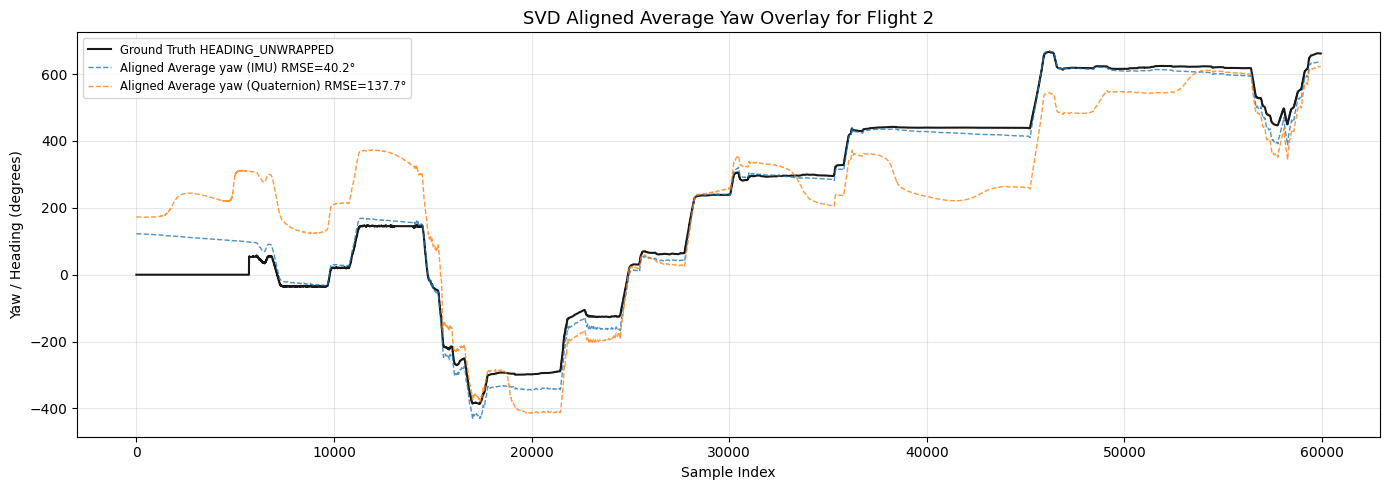

In [30]:
# ── Table D.10 + Figure 3.3(b) — Yaw Evaluation ──

from scipy.interpolate import interp1d
from scripts.imu import quaternion_to_euler, apply_table_d6_filters, detect_imu_takeoff

# ── Filtered IMU at native ~200 Hz ──
f2_imu_filt = apply_table_d6_filters(f2_imu, 'F2')
imu_dt = np.median(np.diff(f2_imu_filt['time']))

# ── Takeoff anchor ──
imu_to_idx = detect_imu_takeoff(f2_imu_filt)
imu_to_t = f2_imu_filt['time'].iloc[imu_to_idx]
gps_to = telemetry.detect_gps_takeoff(df_f2_clean, 3100, 3300, tau=0.5, time_col='SHIFTED_TIME')
offset = gps_to[1] - imu_to_t

imu_gps_time = f2_imu_filt['time'].values + offset
orient_gps_time = f2_orient_sync['time'].values + offset

# ── Gyroscope yaw: integrate at native rate ──
gyro_yaw_c1 = np.degrees(np.cumsum(f2_imu_filt['GYRO_2_c1'].values * imu_dt))
gyro_yaw_c2 = np.degrees(np.cumsum(f2_imu_filt['GYRO_2_c2'].values * imu_dt))
gyro_yaw_avg = (gyro_yaw_c1 + gyro_yaw_c2) / 2

# ── Quaternion yaw: extract at native orient rate ──
_, _, y1 = quaternion_to_euler(
    f2_orient_sync['CORI_0_c1'].values, f2_orient_sync['CORI_1_c1'].values,
    f2_orient_sync['CORI_2_c1'].values, f2_orient_sync['CORI_3_c1'].values)
_, _, y2 = quaternion_to_euler(
    f2_orient_sync['CORI_0_c2'].values, f2_orient_sync['CORI_1_c2'].values,
    f2_orient_sync['CORI_2_c2'].values, f2_orient_sync['CORI_3_c2'].values)
quat_yaw_c1 = np.degrees(np.unwrap(y1))
quat_yaw_c2 = np.degrees(np.unwrap(y2))
quat_yaw_avg = (quat_yaw_c1 + quat_yaw_c2) / 2

# ── Ground truth ──
gps_times = f2['SHIFTED_TIME'].values
heading_gt = np.degrees(np.unwrap(np.radians(f2['HEADING'].values)))

# ── SVD align ──
def svd_align(est, gt):
    valid = np.isfinite(est) & np.isfinite(gt)
    if valid.sum() < 10:
        return np.full_like(est, np.nan), np.nan
    A = np.column_stack([est[valid], np.ones(valid.sum())])
    coeffs, _, _, _ = np.linalg.lstsq(A, gt[valid], rcond=None)
    aligned = np.full_like(est, np.nan)
    aligned[valid] = A @ coeffs
    rmse = np.sqrt(np.mean((aligned[valid] - gt[valid]) ** 2))
    return aligned, rmse

# ── Table D.10 ──
results = []
signals = {
    'IMU': [('C1 yaw', imu_gps_time, gyro_yaw_c1),
            ('C2 yaw', imu_gps_time, gyro_yaw_c2),
            ('Average yaw', imu_gps_time, gyro_yaw_avg)],
    'Quaternion': [('C1 yaw', orient_gps_time, quat_yaw_c1),
                   ('C2 yaw', orient_gps_time, quat_yaw_c2),
                   ('Average yaw', orient_gps_time, quat_yaw_avg)],
}
for method, entries in signals.items():
    for metric, t_src, yaw_src in entries:
        on_gps = interp1d(t_src, yaw_src, kind='linear',
                          bounds_error=False, fill_value=np.nan)(gps_times)
        _, rmse = svd_align(on_gps, heading_gt)
        results.append({'Flight': 'Flight 2', 'Method': method,
                        'Metric': metric, 'RMSE': round(rmse, 2)})

display(pd.DataFrame(results))

# ── Figure 3.3(b) — trim to valid overlap for clean plot ──
imu_start, imu_end = imu_gps_time.min(), imu_gps_time.max()
valid_mask = (f2['SHIFTED_TIME'] >= imu_start) & (f2['SHIFTED_TIME'] <= imu_end)
valid_times = f2.loc[valid_mask, 'SHIFTED_TIME'].values
valid_heading = np.degrees(np.unwrap(np.radians(f2.loc[valid_mask, 'HEADING'].values)))

gyro_avg_valid = interp1d(imu_gps_time, gyro_yaw_avg, bounds_error=False, fill_value=np.nan)(valid_times)
quat_avg_valid = interp1d(orient_gps_time, quat_yaw_avg, bounds_error=False, fill_value=np.nan)(valid_times)

gyro_aligned, rmse_g = svd_align(gyro_avg_valid, valid_heading)
quat_aligned, rmse_q = svd_align(quat_avg_valid, valid_heading)

fig, ax = plt.subplots(figsize=(14, 5))
idx = np.arange(len(valid_times))
ax.plot(idx, valid_heading, 'k-', lw=1.5, label='Ground Truth HEADING_UNWRAPPED', alpha=0.9)
ax.plot(idx, gyro_aligned, '--', color='tab:blue', lw=1,
        label=f'Aligned Average yaw (IMU) RMSE={rmse_g:.1f}°', alpha=0.8)
ax.plot(idx, quat_aligned, '--', color='tab:orange', lw=1,
        label=f'Aligned Average yaw (Quaternion) RMSE={rmse_q:.1f}°', alpha=0.8)
ax.set_title("SVD Aligned Average Yaw Overlay for Flight 2", fontsize=13)
ax.set_xlabel("Sample Index")
ax.set_ylabel("Yaw / Heading (degrees)")
ax.legend(fontsize='small')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_3_3b_yaw_f2.png', dpi=200)
plt.show()

Correlation (sensor vs derived accel): r = 0.0107
Estimated ground speed RMSE: 181.1 m/s


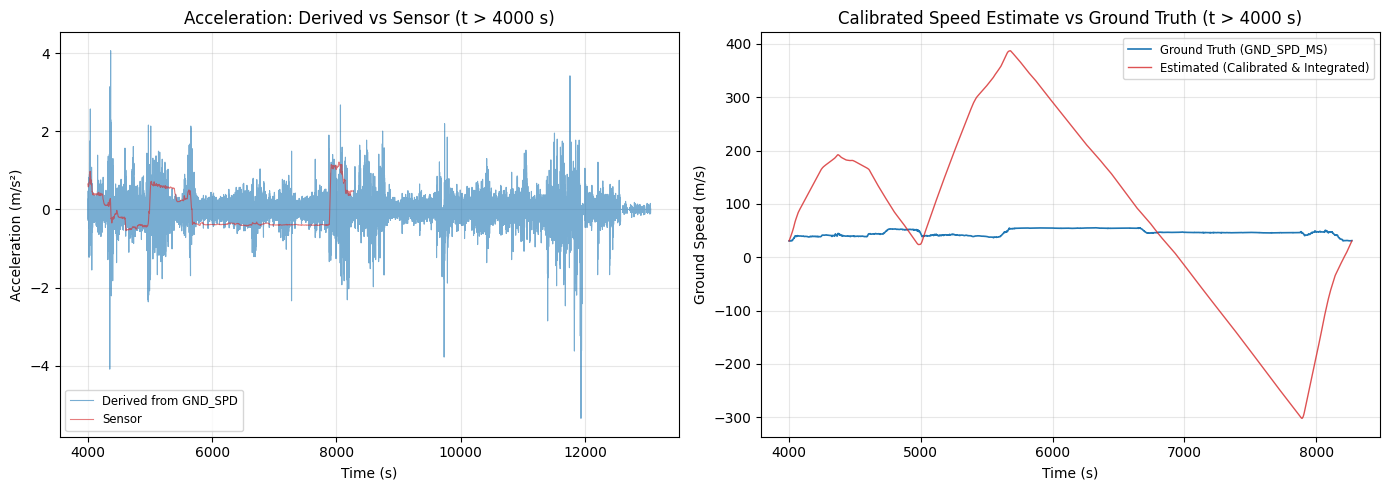


Conclusion: r = 0.0107, RMSE = 181.1 m/s
Accelerometer excluded from INS — unbounded drift when integrated.


In [32]:
# ── Figure 3.4 — IMU Accelerometer as Ground Speed Proxy ──
# (Uses f2, imu_gps_time, offset from the downsample cell above)

f2_imu_filt = imu.apply_table_d6_filters(f2_imu, 'F2')
imu_dt = np.median(np.diff(f2_imu_filt['time']))

accel_avg = (f2_imu_filt['ACCL_0_c1'].values + f2_imu_filt['ACCL_0_c2'].values) / 2
imu_time_shifted = f2_imu_filt['time'].values + offset

# Only evaluate post-takeoff
t_start = 4000
imu_mask = imu_time_shifted >= t_start
gps_mask = f2['SHIFTED_TIME'] >= t_start

gps_speed = f2.loc[gps_mask, 'GND_SPD'].values
gps_time = f2.loc[gps_mask, 'SHIFTED_TIME'].values

# (a) Correlation: sensor accel vs derived accel from GND_SPD
derived_accel = np.gradient(gps_speed, gps_time)
accel_on_gps = interp1d(imu_time_shifted, accel_avg, bounds_error=False,
                        fill_value=np.nan)(gps_time)
valid = np.isfinite(accel_on_gps) & np.isfinite(derived_accel)
correlation = np.corrcoef(accel_on_gps[valid], derived_accel[valid])[0, 1]

# (b) Integrate acceleration to estimate speed
accel_cruise = accel_avg[imu_mask]
imu_time_cruise = imu_time_shifted[imu_mask]
accel_debiased = accel_cruise - np.mean(accel_cruise)
start_speed = f2.loc[gps_mask, 'GND_SPD'].iloc[0]
estimated_speed = start_speed + np.cumsum(accel_debiased * imu_dt)

gt_speed_on_imu = interp1d(gps_time, gps_speed, bounds_error=False,
                           fill_value=np.nan)(imu_time_cruise)
valid_spd = np.isfinite(gt_speed_on_imu)
rmse_speed = np.sqrt(np.mean((estimated_speed[valid_spd] - gt_speed_on_imu[valid_spd]) ** 2))

print(f"Correlation (sensor vs derived accel): r = {correlation:.4f}")
print(f"Estimated ground speed RMSE: {rmse_speed:.1f} m/s")

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(gps_time, derived_accel, color='tab:blue', alpha=0.6, lw=0.8, label='Derived from GND_SPD')
ax1.plot(gps_time, accel_on_gps, color='tab:red', alpha=0.6, lw=0.8, label='Sensor')
ax1.set_title(f"Acceleration: Derived vs Sensor (t > {t_start} s)")
ax1.set_xlabel("Time (s)"); ax1.set_ylabel("Acceleration (m/s²)")
ax1.legend(fontsize='small'); ax1.grid(True, alpha=0.3)

ax2.plot(imu_time_cruise, gt_speed_on_imu, color='tab:blue', lw=1.2, label='Ground Truth (GND_SPD_MS)')
ax2.plot(imu_time_cruise, estimated_speed, color='tab:red', lw=1, alpha=0.8, label='Estimated (Calibrated & Integrated)')
ax2.set_title(f"Calibrated Speed Estimate vs Ground Truth (t > {t_start} s)")
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Ground Speed (m/s)")
ax2.legend(fontsize='small'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_3_4_accel_speed.png', dpi=200)
plt.show()

print(f"\nConclusion: r = {correlation:.4f}, RMSE = {rmse_speed:.1f} m/s")
print("Accelerometer excluded from INS — unbounded drift when integrated.")

In [33]:
# ── Trim to valid overlap and save ──
f2_final = f2[valid_mask].reset_index(drop=True)

print(f"Original:  {len(f2):,} rows")
print(f"Trimmed:   {len(f2_final):,} rows ({f2_final['SHIFTED_TIME'].min():.1f}–{f2_final['SHIFTED_TIME'].max():.1f} s)")

f2_final.to_csv('../f2_final.csv', index=False)
print(f"Saved f2_final.csv — {len(f2_final.columns)} columns")

Original:  118,230 rows
Trimmed:   59,934 rows (1638.2–8271.3 s)
Saved f2_final.csv — 46 columns


In [35]:
import plotly.express as px

fig = px.scatter_3d(
    f2_final, x='LONGITUDE', y='LATITUDE', z='ALTITUDE',
    color='STATE',
    color_discrete_map={
        'TAXI': 'gray', 'TAKEOFF': 'black',
        'CRUISE_0': 'blue', 'ASCENT_1': 'cyan',
        'CRUISE_1': 'green', 'ASCENT_2': 'olive',
        'CRUISE_2': 'orange', 'DESCENT': 'red',
    },
    title='3D Trajectory colored by State',
    opacity=0.6,
)
fig.update_traces(marker_size=2)
fig.show()

In [36]:
# ── Table 3.1 — Flight STATE and SUBSTATE Summary ──
def haversine_cumulative(lats, lons):
    lat_r, lon_r = np.radians(lats), np.radians(lons)
    dlat, dlon = np.diff(lat_r), np.diff(lon_r)
    a = np.sin(dlat/2)**2 + np.cos(lat_r[:-1])*np.cos(lat_r[1:])*np.sin(dlon/2)**2
    return np.sum(2 * 6_371_000 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))) / 1000

rows = []
for state in ['CRUISE_0', 'CRUISE_1']:
    for sub in ['OUTBOUND', 'TURNING', 'INBOUND']:
        s = f2_final[(f2_final['STATE'] == state) & (f2_final['SUBSTATE'] == sub)]
        if s.empty:
            continue
        rows.append({
            'STATE': state, 'SUBSTATE': sub,
            'Avg Altitude (m)': round(s['ALTITUDE'].mean(), 2),
            'Avg Ground Speed (m/s)': round(s['GND_SPD'].mean(), 2),
            'Distance Traveled (km)': round(haversine_cumulative(s['LATITUDE'].values, s['LONGITUDE'].values), 2),
            'GNSS Status': 'AVAILABLE' if sub == 'OUTBOUND' else 'DENIED',
        })

display(pd.DataFrame(rows))

,STATE,SUBSTATE,Avg Altitude (m),Avg Ground Speed (m/s),Distance Traveled (km),GNSS Status
0,CRUISE_0,OUTBOUND,430.99,35.41,33.96,AVAILABLE
1,CRUISE_0,TURNING,433.55,42.19,31.76,DENIED
2,CRUISE_0,INBOUND,447.08,44.75,33.59,DENIED
3,CRUISE_1,OUTBOUND,2189.66,54.54,52.86,AVAILABLE
4,CRUISE_1,TURNING,2182.36,47.94,58.44,DENIED
5,CRUISE_1,INBOUND,2172.35,46.22,53.16,DENIED
